# LinkedIn Job Applications — Data Extraction & Analysis

Parses saved HTML pages from LinkedIn's "My Jobs / Applied Jobs" view,
extracts structured application data, and runs exploratory analysis
matching the depth of the Handshake analysis notebook.

In [1]:
# ── Install dependencies if needed ──────────────────────────────────────────
# %pip install beautifulsoup4 pandas matplotlib seaborn --quiet

In [2]:
import re
import glob
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)

## 1. Parse HTML files

LinkedIn's saved "Applied Jobs" pages use CSS class-based markup rather than
`aria-label` strings. We locate each job card via its `/jobs/view/` link, then
walk the surrounding DOM to pull out title, company, location, applied date,
and application status.

**How to save your pages:** Open LinkedIn → Jobs → My Jobs → Applied,
scroll to the bottom, then File → Save As → Webpage, Complete.
Name the files `0.html`, `1.html`, … to match the pattern below.

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
# Point HTML_DIR at the folder containing your saved LinkedIn HTML files.
# Expected names: 0.html, 1.html, 2.html, …  (any numeric stem works)
HTML_DIR     = Path('.')     # <-- change if files are in a sub-folder
FILE_PATTERN = '*.html'

html_files = sorted(
    HTML_DIR.glob(FILE_PATTERN),
    key=lambda p: int(re.sub(r'\D', '', p.stem) or -1)
)
print(f'Found {len(html_files)} HTML file(s):')
for f in html_files:
    print(' ', f.name)

Found 70 HTML file(s):
  1.html
  2.html
  3.html
  4.html
  5.html
  6.html
  7.html
  8.html
  9.html
  10.html
  11.html
  12.html
  13.html
  14.html
  15.html
  16.html
  17.html
  18.html
  19.html
  20.html
  21.html
  22.html
  23.html
  24.html
  25.html
  26.html
  27.html
  28.html
  29.html
  30.html
  31.html
  32.html
  33.html
  34.html
  35.html
  36.html
  37.html
  38.html
  39.html
  40.html
  41.html
  42.html
  43.html
  44.html
  45.html
  46.html
  47.html
  48.html
  49.html
  50.html
  51.html
  52.html
  53.html
  54.html
  55.html
  56.html
  57.html
  58.html
  59.html
  60.html
  61.html
  62.html
  63.html
  64.html
  65.html
  66.html
  67.html
  68.html
  69.html
  70.html


In [4]:
# ── Helper: parse a single LinkedIn Applied-Jobs HTML page ──────────────────

def _text(tag):
    """Return stripped text from a tag, or None."""
    return tag.get_text(strip=True) if tag else None


def parse_location(raw: str):
    """
    Split a LinkedIn location string into (work_type, city, state).
    Examples of raw strings seen in the wild:
      'San Francisco, CA (Hybrid)'
      'Remote'
      'New York, NY'
      'Greater Chicago Area'
    """
    if not raw:
        return None, None, None

    # Work type from parenthetical or leading keyword
    wt_map = {'remote': 'Remote', 'hybrid': 'Hybrid', 'on-site': 'Onsite', 'onsite': 'Onsite'}
    work_type = None
    m_paren = re.search(r'\(([^)]+)\)', raw)
    if m_paren:
        candidate = m_paren.group(1).lower().strip()
        work_type = wt_map.get(candidate)
    if not work_type:
        for kw, label in wt_map.items():
            if raw.lower().startswith(kw):
                work_type = label
                break

    # Strip the parenthetical before extracting city/state
    clean = re.sub(r'\s*\([^)]*\)', '', raw).strip().rstrip(',')

    # City, ST  pattern
    m = re.match(r'^(.+?),\s*([A-Z]{2})$', clean)
    if m:
        return work_type, m.group(1).strip(), m.group(2).strip()

    # Fallback: treat whole string as city, no state
    city = clean if clean.lower() not in ('remote',) else None
    return work_type, city, None


def parse_company_location(raw: str):
    """
    LinkedIn often encodes company and location together as 'Company · Location'.
    Returns (company, location_raw).
    """
    if not raw:
        return None, None
    parts = [p.strip() for p in raw.split('\u00b7')]  # middle-dot U+00B7
    if len(parts) >= 2:
        return parts[0], parts[1]
    return parts[0], None


def parse_applied_date(raw: str):
    """
    Strip 'Applied ' prefix (e.g. 'Applied January 15, 2025') and return
    the remaining date string for pd.to_datetime.
    """
    if not raw:
        return None
    return raw.replace('Applied ', '').strip()


def parse_file(path: Path) -> list:
    """Parse one saved LinkedIn Applied-Jobs HTML page and return a list of record dicts."""
    with open(path, 'r', encoding='utf-8', errors='replace') as fh:
        soup = BeautifulSoup(fh, 'html.parser')

    seen_urls = set()
    records = []

    for link in soup.find_all('a', href=lambda h: h and '/jobs/view/' in h):
        url = link.get('href', '').split('?')[0]  # strip query params
        if url in seen_urls:
            continue
        seen_urls.add(url)

        # Extract job ID from URL
        jid_m = re.search(r'/jobs/view/(\d+)', url)
        job_id = jid_m.group(1) if jid_m else None

        # Walk up to a sensible card container (try several depths)
        container = link
        for _ in range(6):
            container = container.parent
            if container is None:
                break
            text_len = len(container.get_text())
            if text_len > 60:
                break

        if container is None:
            continue

        all_texts = [t.get_text(strip=True) for t in container.find_all(['p', 'span', 'h3', 'h4'])
                     if t.get_text(strip=True)]

        # ── Title: usually the first bold/heading or the link text itself ──
        title = _text(link) or (all_texts[0] if all_texts else None)

        # ── Company · Location  (typically the second distinct text block) ──
        company_loc_raw = all_texts[1] if len(all_texts) > 1 else None
        company, loc_raw = parse_company_location(company_loc_raw)

        # ── Applied date (look for 'Applied …' pattern anywhere in card) ──
        date_raw = next(
            (t for t in all_texts if t.lower().startswith('applied')), None
        )

        # ── Status (e.g. 'Viewed', 'Application sent', 'Interviewing') ──
        status_keywords = {
            'viewed': 'Viewed',
            'application sent': 'Application Sent',
            'interviewing': 'Interviewing',
            'offer': 'Offer',
            'rejected': 'Rejected',
            'closed': 'Closed',
            'no longer accepting': 'Closed',
        }
        status = None
        for t in all_texts:
            tl = t.lower()
            for kw, label in status_keywords.items():
                if kw in tl:
                    status = label
                    break
            if status:
                break

        records.append({
            'job_id':        job_id,
            'title':         title,
            'company':       company,
            'location_raw':  loc_raw,
            'date_applied_raw': parse_applied_date(date_raw),
            'status':        status,
            'url':           url,
            'source_page':   path.stem,
        })

    return records

In [5]:
all_records = []
for f in html_files:
    recs = parse_file(f)
    print(f'{f.name:20s}  →  {len(recs):3d} rows')
    all_records.extend(recs)

print(f'\nTotal records extracted: {len(all_records)}')

1.html                →   10 rows
2.html                →   10 rows
3.html                →   10 rows
4.html                →   10 rows
5.html                →   10 rows
6.html                →   10 rows
7.html                →   10 rows
8.html                →   10 rows
9.html                →   10 rows
10.html               →   10 rows
11.html               →   10 rows
12.html               →   10 rows
13.html               →    8 rows
14.html               →   10 rows
15.html               →   10 rows
16.html               →    9 rows
17.html               →   10 rows
18.html               →   10 rows
19.html               →   10 rows
20.html               →   10 rows
21.html               →   10 rows
22.html               →   10 rows
23.html               →    9 rows
24.html               →   10 rows
25.html               →   10 rows
26.html               →    9 rows
27.html               →   10 rows
28.html               →   10 rows
29.html               →   10 rows
30.html       

## 2. Build & clean the DataFrame

In [6]:
df = pd.DataFrame(all_records)

# Parse location into components
loc = df['location_raw'].apply(
    lambda x: pd.Series(parse_location(x), index=['work_type', 'city', 'state'])
)
df = pd.concat([df, loc], axis=1)

# Parse applied date (LinkedIn uses formats like 'January 15, 2025' or '2025-01-15')
df['date_applied'] = pd.to_datetime(df['date_applied_raw'], errors='coerce', format='mixed')
df['year_applied']  = df['date_applied'].dt.year
df['month_applied'] = df['date_applied'].dt.to_period('M')

# Normalise status — fill nulls with 'Applied' (LinkedIn default)
df['status'] = df['status'].fillna('Applied').str.strip().str.title()

# Drop exact duplicates (same job ID)
df = df.drop_duplicates(subset='job_id').reset_index(drop=True)

print(df.shape)
df.head(10)

(681, 14)


,job_id,title,company,location_raw,date_applied_raw,status,url,source_page,work_type,city,state,date_applied,year_applied,month_applied
0,4402760008,Data EngineerAddison Group · United States (Remote)Applied 3w ago(No longer ...,Addison Group,United States (Remote),3w ago,Closed,https://www.linkedin.com/jobs/view/4402760008/,1,Remote,United States,None,NaT,NaN,NaT
1,4389759683,"Data Scientist / Engineer (Healthcare Solutions)Shift Technology · Boston, M...",Shift Technology,"Boston, MA (Hybrid)",1d ago,Applied,https://www.linkedin.com/jobs/view/4389759683/,1,Hybrid,Boston,MA,NaT,NaN,NaT
2,4394477424,"Junior Support EngineerBracebridge Capital, LLC · Boston, MAApplied 1d ago(R...","Bracebridge Capital, LLC","Boston, MA",1d ago,Applied,https://www.linkedin.com/jobs/view/4394477424/,1,None,Boston,MA,NaT,NaN,NaT
3,4397324427,Associate – AI & Automation (Early Career / New Graduate)BETSOL · Broomfield...,BETSOL,"Broomfield, CO (On-site)",1w ago,Closed,https://www.linkedin.com/jobs/view/4397324427/,1,Onsite,Broomfield,CO,NaT,NaN,NaT
4,4389802889,"Software Engineer, Data EngineeringNeuralink · Fremont, CAApplied 3w ago(Rep...",Neuralink,"Fremont, CA",3w ago,Applied,https://www.linkedin.com/jobs/view/4389802889/,1,None,Fremont,CA,NaT,NaN,NaT
5,4408792561,"IT Support/Entry-Level Help DeskRobert Half · Boulder, CO (On-site)Applied 1...",Robert Half,"Boulder, CO (On-site)",1w ago,Closed,https://www.linkedin.com/jobs/view/4408792561/,1,Onsite,Boulder,CO,NaT,NaN,NaT
6,4410711254,Junior Data AnalystHelic & Co. · United States (Remote)Applied 1w ago(No lon...,Helic & Co.,United States (Remote),1w ago,Closed,https://www.linkedin.com/jobs/view/4410711254/,1,Remote,United States,None,NaT,NaN,NaT
7,4398174305,"Technical Support AnalystAimHire · Denver, CO (On-site)Applied 1w ago(No lon...",AimHire,"Denver, CO (On-site)",1w ago,Closed,https://www.linkedin.com/jobs/view/4398174305/,1,Onsite,Denver,CO,NaT,NaN,NaT
8,4408101597,"Financial AnalystSoTalent · Grand Rapids, MI (On-site)Applied 6d ago(No long...",SoTalent,"Grand Rapids, MI (On-site)",6d ago,Closed,https://www.linkedin.com/jobs/view/4408101597/,1,Onsite,Grand Rapids,MI,NaT,NaN,NaT
9,4382065637,Business AnalystEmpower · United States (Remote)Applied 1mo ago(Reposted 6d ...,Empower,United States (Remote),1mo ago,Applied,https://www.linkedin.com/jobs/view/4382065637/,1,Remote,United States,None,NaT,NaN,NaT


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   job_id            681 non-null    object        
 1   title             681 non-null    object        
 2   company           681 non-null    object        
 3   location_raw      676 non-null    object        
 4   date_applied_raw  681 non-null    object        
 5   status            681 non-null    object        
 6   url               681 non-null    object        
 7   source_page       681 non-null    object        
 8   work_type         663 non-null    object        
 9   city              676 non-null    object        
 10  state             390 non-null    object        
 11  date_applied      0 non-null      datetime64[ns]
 12  year_applied      0 non-null      float64       
 13  month_applied     0 non-null      period[M]     
dtypes: datetime64[ns](1), floa

In [8]:
print('=== Status ===')
print(df['status'].value_counts(), '\n')

print('=== Work type ===')
print(df['work_type'].value_counts(), '\n')

print('=== Top 10 states ===')
print(df['state'].value_counts().head(10))

=== Status ===
status
Closed     645
Applied     35
Offer        1
Name: count, dtype: int64 

=== Work type ===
work_type
Onsite    247
Remote    229
Hybrid    187
Name: count, dtype: int64 

=== Top 10 states ===
state
IL    90
NY    78
CA    63
TX    20
MA    19
NJ    17
MI    16
FL    10
CO    10
NC     8
Name: count, dtype: int64


## 3. Analysis & Visualisations

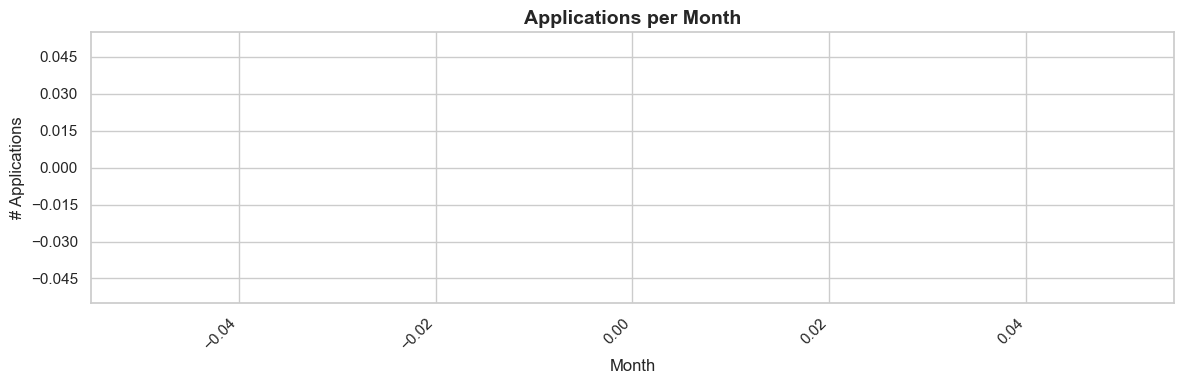

In [9]:
# ── 3.1  Applications over time ──────────────────────────────────────────────
monthly = (
    df.groupby('month_applied')
      .size()
      .reset_index(name='count')
      .sort_values('month_applied')
)
monthly['month_str'] = monthly['month_applied'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['month_str'], monthly['count'], color=sns.color_palette('muted')[0])
ax.set_title('Applications per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('# Applications')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

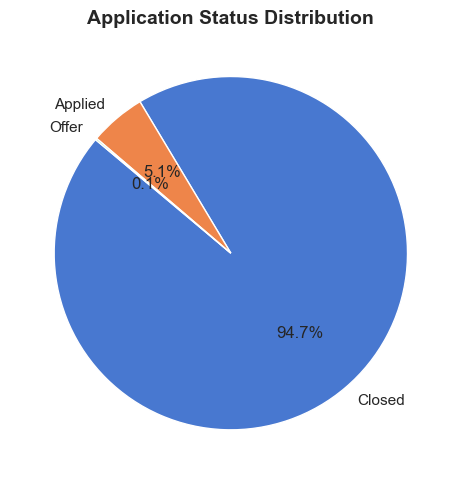

In [10]:
# ── 3.2  Application status breakdown ────────────────────────────────────────
status_counts = df['status'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('muted', len(status_counts))
ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
)
ax.set_title('Application Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/9b/pqv3317s0y7gshfwzdd28mfw0000gn/T/ipykernel_68859/1608633124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax, palette='muted')


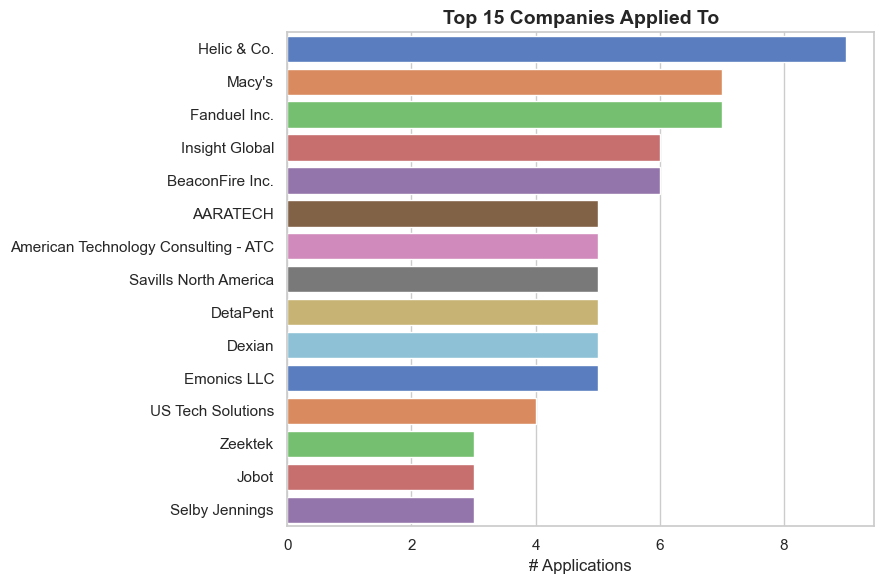

In [11]:
# ── 3.3  Top companies applied to ───────────────────────────────────────────
top_companies = df['company'].value_counts().dropna().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax, palette='muted')
ax.set_title('Top 15 Companies Applied To', fontsize=14, fontweight='bold')
ax.set_xlabel('# Applications')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

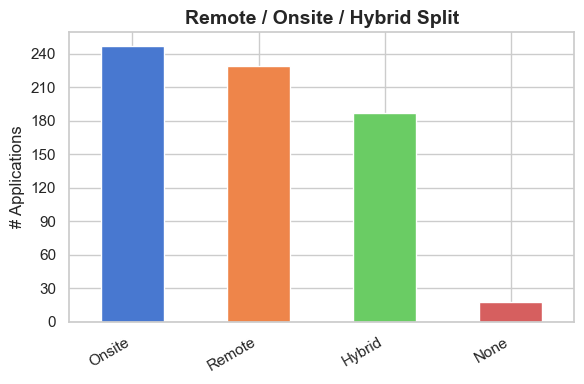

In [12]:
# ── 3.4  Work type breakdown ──────────────────────────────────────────────────
wt = df['work_type'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(6, 4))
wt.plot(kind='bar', ax=ax,
        color=sns.color_palette('muted', len(wt)), edgecolor='white')
ax.set_title('Remote / Onsite / Hybrid Split', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('# Applications')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

/var/folders/9b/pqv3317s0y7gshfwzdd28mfw0000gn/T/ipykernel_68859/3888222443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, ax=ax, palette='muted')


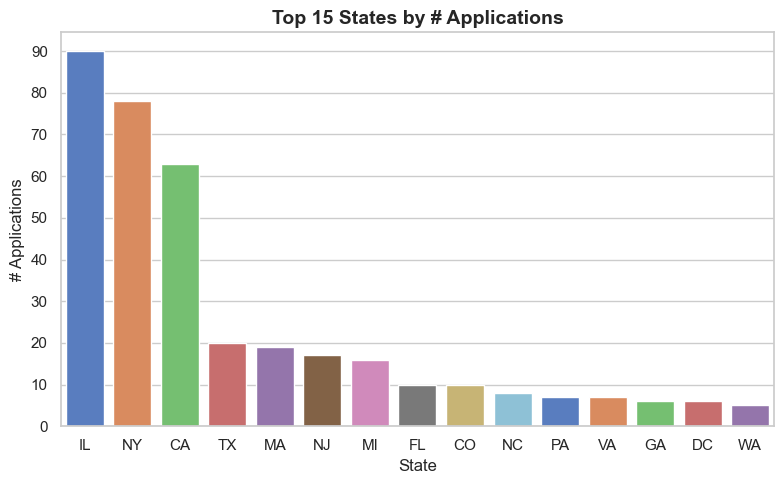

In [13]:
# ── 3.5  Top states ──────────────────────────────────────────────────────────
top_states = df['state'].value_counts().dropna().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_states.index, y=top_states.values, ax=ax, palette='muted')
ax.set_title('Top 15 States by # Applications', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('# Applications')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

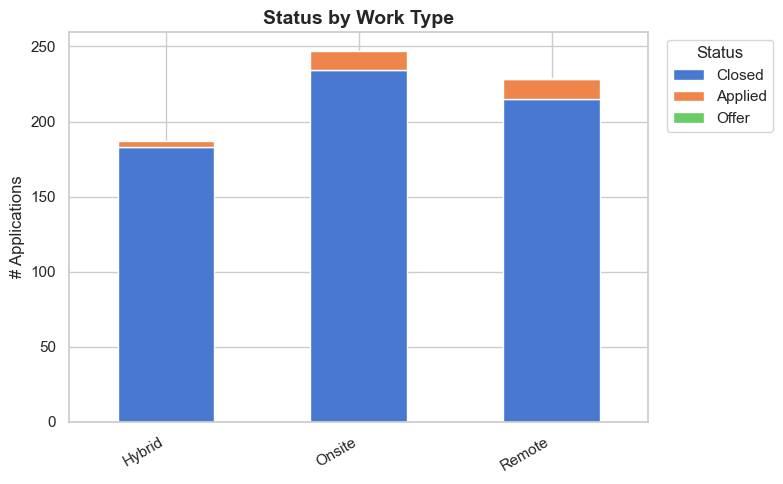

In [14]:
# ── 3.6  Status by work type (stacked bar) ───────────────────────────────────
cross = (
    df.groupby(['work_type', 'status'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=df['status'].value_counts().index)
)

cross.plot(kind='bar', stacked=True, figsize=(8, 5),
           color=sns.color_palette('muted', cross.shape[1]),
           edgecolor='white')
plt.title('Status by Work Type', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('# Applications')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
# ── 3.7  Summary stats ───────────────────────────────────────────────────────
total       = len(df)
applied     = (df['status'].str.lower() == 'applied').sum()
viewed      = (df['status'].str.lower() == 'viewed').sum()
sent        = (df['status'].str.lower() == 'application sent').sum()
interviewing = (df['status'].str.lower() == 'interviewing').sum()
rejected    = (df['status'].str.lower() == 'rejected').sum()
closed      = (df['status'].str.lower() == 'closed').sum()
unique_co   = df['company'].nunique()

date_min = df['date_applied'].min()
date_max = df['date_applied'].max()
date_range = (
    f"{date_min.date()}  →  {date_max.date()}"
    if pd.notna(date_min) and pd.notna(date_max)
    else 'N/A (no parseable dates — check date_applied_raw column)'
)

print('━' * 48)
print('  SUMMARY')
print('━' * 48)
print(f'  Total applications   : {total}')
print(f'  Date range           : {date_range}')
print(f'  Unique companies     : {unique_co}')
print(f'  Status — Applied     : {applied}')
print(f'  Status — Viewed      : {viewed}')
print(f'  Status — Sent        : {sent}')
print(f'  Status — Interviewing: {interviewing}')
print(f'  Status — Rejected    : {rejected}')
print(f'  Status — Closed      : {closed}')
print('━' * 48)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total applications   : 681
  Date range           : N/A (no parseable dates — check date_applied_raw column)
  Unique companies     : 554
  Status — Applied     : 35
  Status — Viewed      : 0
  Status — Sent        : 0
  Status — Interviewing: 0
  Status — Rejected    : 0
  Status — Closed      : 645
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 4. State Distribution — Inline Summary

In [16]:
# ── 4.1  All states as inline percentages ────────────────────────────────────
state_pct = (
    df['state']
    .value_counts(dropna=False)
    .pipe(lambda s: (s / s.sum() * 100).round(1))
)

state_pct.index = state_pct.index.fillna('Unknown/Intl')

inline = '  |  '.join(f"{state}: {pct}%" for state, pct in state_pct.items())
print('State breakdown (% of all applications)\n')
print(inline)

State breakdown (% of all applications)

Unknown/Intl: 42.7%  |  IL: 13.2%  |  NY: 11.5%  |  CA: 9.3%  |  TX: 2.9%  |  MA: 2.8%  |  NJ: 2.5%  |  MI: 2.3%  |  CO: 1.5%  |  FL: 1.5%  |  NC: 1.2%  |  PA: 1.0%  |  VA: 1.0%  |  GA: 0.9%  |  DC: 0.9%  |  WA: 0.7%  |  LA: 0.7%  |  TN: 0.6%  |  MD: 0.6%  |  CT: 0.4%  |  OR: 0.3%  |  AZ: 0.3%  |  OH: 0.1%  |  MN: 0.1%  |  UT: 0.1%  |  IN: 0.1%  |  IA: 0.1%  |  RI: 0.1%  |  NV: 0.1%  |  MS: 0.1%


## 5. Export clean DataFrame to CSV

In [17]:
export_cols = ['job_id', 'company', 'title',
               'location_raw', 'work_type', 'city', 'state',
               'date_applied', 'status', 'url', 'source_page']

out_path = 'linkedin_applications.csv'
df[export_cols].to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(df)} rows)')

Saved → linkedin_applications.csv  (681 rows)


In [18]:
# ── Search applications by title keyword ─────────────────────────────────────
SEARCH = "analyst"   # <-- change this

mask = df['title'].str.contains(SEARCH, case=False, na=False)
results = df[mask][['title', 'company', 'location_raw', 'date_applied', 'status']].copy()
results['date_applied'] = results['date_applied'].dt.strftime('%Y-%m-%d')

print(f'Search: "{SEARCH}"  →  {len(results)} match(es)\n')
print(f'{"#":<4} {"Title":<55} {"Company":<30} {"Location":<30} {"Date":<12} {"Status"}')
print('─' * 145)
for i, (_, row) in enumerate(results.iterrows(), 1):
    print(f'{i:<4} {str(row.title)[:54]:<55} {str(row.company)[:29]:<30} '
          f'{str(row.location_raw)[:29]:<30} {str(row.date_applied):<12} {row.status}')

Search: "analyst"  →  381 match(es)

#    Title                                                   Company                        Location                       Date         Status
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1    Junior Data AnalystHelic & Co. · United States (Remote  Helic & Co.                    United States (Remote)         nan          Closed
2    Technical Support AnalystAimHire · Denver, CO (On-site  AimHire                        Denver, CO (On-site)           nan          Closed
3    Financial AnalystSoTalent · Grand Rapids, MI (On-site)  SoTalent                       Grand Rapids, MI (On-site)     nan          Closed
4    Business AnalystEmpower · United States (Remote)Applie  Empower                        United States (Remote)         nan          Applied
5    Product AnalystSprocket Sports · Greater Chicago Area   Sprocket Sports                Greater C

In [ ]:
# ── Search applications by company name ──────────────────────────────────────
SEARCH = "berkeley"   # <-- change this

mask = df['company'].str.contains(SEARCH, case=False, na=False)
results = df[mask][['title', 'company', 'location_raw', 'date_applied', 'status']].copy()
results['date_applied'] = results['date_applied'].dt.strftime('%Y-%m-%d')

print(f'Search company: "{SEARCH}"  →  {len(results)} match(es)\n')
print(f'{"#":<4} {"Title":<55} {"Company":<30} {"Location":<30} {"Date":<12} {"Status"}')
print('─' * 145)

for i, (_, row) in enumerate(results.iterrows(), 1):
    print(f'{i:<4} {str(row.title)[:54]:<55} '
          f'{str(row.company)[:29]:<30} '
          f'{str(row.location_raw)[:29]:<30} '
          f'{str(row.date_applied):<12} {row.status}')

Search company: "berkely"  →  0 match(es)

#    Title                                                   Company                        Location                       Date         Status
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
